## Holiday Package Prediciton

### Problem statement.

"Trips & Travel.Com" company wants to enable and establish a viable business model to expand the customer base.
One of the ways to expand the customer base is to introduce a new offering of packages. Currently, there are 5 types of packages the company is offering \* Basic, Standard, Deluxe, Super Deluxe, King. Looking at the data of the last year, we observed that 18% of the customers purchased the packages. However, the marketing cost was quite high because customers were contacted at random without looking at the available information.
The company is now planning to launch a new product i.e. Wellness Tourism Package. Wellness Tourism is defined as Travel that allows the traveler to maintain, enhance or kick-start a healthy lifestyle, and support or increase one's sense of well-being.
However, this time company wants to harness the available data of existing and potential customers to make the marketing expenditure more efficient.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
df = pd.read_csv("s:/AI ML/Machine Learning/Datasets/Travel.csv")
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [3]:
# Data Cleaning

df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [4]:
df.shape

(4888, 20)

In [5]:
df["MaritalStatus"].value_counts()

MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64

In [6]:
df["Gender"].value_counts()

Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64

In [7]:
df["Gender"] = df["Gender"].replace("Fe Male", "Female")
df["MaritalStatus"] = df["MaritalStatus"].replace("Unmarried", "Single")

In [8]:
df.drop("CustomerID", axis=1, inplace=True)

In [9]:
# Check Missing values
features_na = [features for features in df.columns if df[features].isnull().sum() >= 1]
for feature in features_na:
    print(feature, np.round(df[feature].isnull().mean()*100, 5))

Age 4.62357
TypeofContact 0.51146
DurationOfPitch 5.13502
NumberOfFollowups 0.92062
PreferredPropertyStar 0.53191
NumberOfTrips 2.86416
NumberOfChildrenVisiting 1.35025
MonthlyIncome 4.76678


In [10]:
# statistics on numerical cols (null)
df[features_na].select_dtypes(exclude="object").describe()

,Age,DurationOfPitch,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,NumberOfChildrenVisiting,MonthlyIncome
count,4662.000000,4637.000000,4843.000000,4862.000000,4748.000000,4822.000000,4655.000000
mean,37.622265,15.490835,3.708445,3.581037,3.236521,1.187267,23619.853491
std,9.316387,8.519643,1.002509,0.798009,1.849019,0.857861,5380.698361
min,18.000000,5.000000,1.000000,3.000000,1.000000,0.000000,1000.000000
25%,31.000000,9.000000,3.000000,3.000000,2.000000,1.000000,20346.000000
50%,36.000000,13.000000,4.000000,3.000000,3.000000,1.000000,22347.000000
75%,44.000000,20.000000,4.000000,4.000000,4.000000,2.000000,25571.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,3.000000,98678.000000


In [11]:
# Replacing null values with
# Age: Median
# TypefContact: Mode
# DurationOfPitch: Median
# NumberOfFollowups: Mode
# PreferredPropertyStar: Mode
# NumberofTrips: Median
# NumberOfChildrenVisiting: Mode
# MonthlyIncome: Median
df["Age"] = df.Age.fillna(df.Age.median())
df["TypeofContact"] = df.TypeofContact.fillna(df.TypeofContact.mode()[0])
df["DurationOfPitch"] = df.DurationOfPitch.fillna(df.DurationOfPitch.median())
df["NumberOfFollowups"] = df.NumberOfFollowups.fillna(df.NumberOfFollowups.mode()[0])
df["PreferredPropertyStar"] = df.PreferredPropertyStar.fillna(
    df.PreferredPropertyStar.mode()[0]
)
df["NumberOfTrips"] = df.NumberOfTrips.fillna(df.NumberOfTrips.median())
df["NumberOfChildrenVisiting"] = df.NumberOfChildrenVisiting.fillna(
    df.NumberOfChildrenVisiting.mode()[0]
)
df["MonthlyIncome"] = df.MonthlyIncome.fillna(df.MonthlyIncome.median())

In [12]:
df.isnull().sum()

ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [13]:
df.columns

Index(['ProdTaken', 'Age', 'TypeofContact', 'CityTier', 'DurationOfPitch',
       'Occupation', 'Gender', 'NumberOfPersonVisiting', 'NumberOfFollowups',
       'ProductPitched', 'PreferredPropertyStar', 'MaritalStatus',
       'NumberOfTrips', 'Passport', 'PitchSatisfactionScore', 'OwnCar',
       'NumberOfChildrenVisiting', 'Designation', 'MonthlyIncome'],
      dtype='str')

In [14]:
# Feature Extraction
# Discrete Features
# Continuous Features

df["Total_Visits"] = df["NumberOfChildrenVisiting"] + df["NumberOfPersonVisiting"]

In [15]:
# Numerical Features (exclude target column ProdTaken)
num_features = [
    feature
    for feature in df.select_dtypes(include="number").columns.tolist()
    if feature != "ProdTaken"
]
print(f"Count of Numerical Features: {len(num_features)}\nFeatures: \n{num_features}")

Count of Numerical Features: 13
Features: 
['Age', 'CityTier', 'DurationOfPitch', 'NumberOfPersonVisiting', 'NumberOfFollowups', 'PreferredPropertyStar', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore', 'OwnCar', 'NumberOfChildrenVisiting', 'MonthlyIncome', 'Total_Visits']


In [16]:
# Categorical Features
cat_features = [feature for feature in df.select_dtypes(include=["object", "category"])]
print(f"Count of Numberical Features: {len(cat_features)}\nFeatures: \n{cat_features}")

Count of Numberical Features: 6
Features: 
['TypeofContact', 'Occupation', 'Gender', 'ProductPitched', 'MaritalStatus', 'Designation']


In [17]:
# Discrete Features
dis_features = [feature for feature in num_features if len(df[feature].unique())  <= 25]
print(f"Count of Discrete Features: {len(dis_features)}\nFeatures: \n{dis_features}")

Count of Discrete Features: 10
Features: 
['CityTier', 'NumberOfPersonVisiting', 'NumberOfFollowups', 'PreferredPropertyStar', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore', 'OwnCar', 'NumberOfChildrenVisiting', 'Total_Visits']


In [18]:
# Continuous Features
cont_features = [feature for feature in num_features if len(df[feature].unique()) > 25]
print(
    f"Count of Continuous Features: {len(cont_features)}\nFeatures: \n{cont_features}"
)

Count of Continuous Features: 3
Features: 
['Age', 'DurationOfPitch', 'MonthlyIncome']


In [19]:
X = df.drop("ProdTaken", axis=1)
y = df["ProdTaken"]

In [20]:
# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=52
)

In [21]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       4888 non-null   float64
 1   TypeofContact             4888 non-null   str    
 2   CityTier                  4888 non-null   int64  
 3   DurationOfPitch           4888 non-null   float64
 4   Occupation                4888 non-null   str    
 5   Gender                    4888 non-null   str    
 6   NumberOfPersonVisiting    4888 non-null   int64  
 7   NumberOfFollowups         4888 non-null   float64
 8   ProductPitched            4888 non-null   str    
 9   PreferredPropertyStar     4888 non-null   float64
 10  MaritalStatus             4888 non-null   str    
 11  NumberOfTrips             4888 non-null   float64
 12  Passport                  4888 non-null   int64  
 13  PitchSatisfactionScore    4888 non-null   int64  
 14  OwnCar             

In [22]:
# Column Transformer with 3 types of transformers
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

num_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

ct = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
        ("StandardScaler", num_transformer, num_features),
    ]
)

In [23]:
X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)

In [29]:
!pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   - -------------------------------------- 1.6/48.9 MB 5.8 MB/s eta 0:00:09
   -- ------------------------------------- 2.6/48.9 MB 5.6 MB/s eta 0:00:09
   -- ------------------------------------- 3.7/48.9 MB 5.4 MB/s eta 0:00:09
   ---- ----------------------------------- 5.0/48.9 MB 5.5 MB/s eta 0:00:08
   ----- ---------------------------------- 6.3/48.9 MB 5.7 MB/s eta 0:00:08
   ------ --------------------------------- 7.9/48.9 MB 6.0 MB/s eta 0:00:07
   ------- -------------------------------- 8.7/48.9 MB 5.7 MB/s eta 0:00:08
   ------- -------------------------------- 9.7/48.9 MB 5.6 MB/s eta 0:00:07
   --------- ------------------------------ 11.3/48.9 MB 5.8 MB/s eta 0:00:07
   ---------- ----------------------------- 12.6/48.9 MB 5.9 MB/s eta 0:00:07
   ----------- ---------------------------- 14.2/48.9 MB 6.1 MB/s eta 0:00:06
   -------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    roc_auc_score,
    roc_curve,
    f1_score,
)

In [ ]:
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(),
}

for i in range(len(list(models))):
    model = list(models.values())[i]
    name = list(models.keys())[i]
    model.fit(X_train, y_train)

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training set performance
    print(name, "Performance for training set")
    print(f"Accuracy Score: {accuracy_score(y_train,y_train_pred)}")
    print(f"ROC AUC Score: {roc_auc_score(y_train,y_train_pred)}")
    print(f"F1 Score: {f1_score(y_train,y_train_pred)}")
    print(f"Recall Score: {recall_score(y_train,y_train_pred)}")
    print(f"Precision Score: {precision_score(y_train,y_train_pred)}")
    print("-------------------------------")
    # Testing set performance
    print(name, "Performance for testing set")
    print(f"Accuracy Score: {accuracy_score(y_test,y_test_pred)}")
    print(f"ROC AUC Score: {roc_auc_score(y_test,y_test_pred)}")
    print(f"F1 Score: {f1_score(y_test,y_test_pred)}")
    print(f"Recall Score: {recall_score(y_test,y_test_pred)}")
    print(f"Precision Score: {precision_score(y_test,y_test_pred)}\n")

Decision Tree Performance for training set
Accuracy Score: 1.0
ROC AUC Score: 1.0
F1 Score: 1.0
Recall Score: 1.0
Precision Score: 1.0
-------------------------------
Decision Tree Performance for testing set
Accuracy Score: 0.9151329243353783
ROC AUC Score: 0.8723772117542669
F1 Score: 0.7909319899244333
Recall Score: 0.8010204081632653
Precision Score: 0.7810945273631841

Random Forest Performance for training set
Accuracy Score: 1.0
ROC AUC Score: 1.0
F1 Score: 1.0
Recall Score: 1.0
Precision Score: 1.0
-------------------------------
Random Forest Performance for testing set
Accuracy Score: 0.9151329243353783
ROC AUC Score: 0.8054700140925936
F1 Score: 0.746177370030581
Recall Score: 0.6224489795918368
Precision Score: 0.9312977099236641

Gradient Boost Performance for training set
Accuracy Score: 0.889002557544757
ROC AUC Score: 0.7285608133651023
F1 Score: 0.6125
Recall Score: 0.47375690607734805
Precision Score: 0.8661616161616161
-------------------------------
Gradient Boost P

In [26]:
# Hyperparameter tuning using RandomisedSearchCV

rf_param = {
    "n_estimators": [100, 200, 300, 500, 800, 1000],
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [5, 8, 15, None, 10],
    "max_features": [5, 7, "auto", 8],
    "min_samples_split": [2, 8, 15, 20],
}
xb_param = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [3, 5, 7, 9, 12],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [1, 1.5, 2, 5],
}

In [27]:
randomcv_models = [
    ("Random Forest", RandomForestClassifier(), rf_param),
    ("XGBoost", XGBClassifier(), xb_param),
]

In [28]:
from sklearn.model_selection import RandomizedSearchCV

for name, model, params in randomcv_models:
    random = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=100,
        cv=3,
        verbose=2,
        n_jobs=-1,
    )
    random.fit(X_train, y_train)

    y_train_pred = random.predict(X_train)
    y_test_pred = random.predict(X_test)

    print(random.best_params_)
    print(name, "Performance for training set")
    print(f"Accuracy Score: {accuracy_score(y_train,y_train_pred)}")
    print(f"ROC AUC Score: {roc_auc_score(y_train,y_train_pred)}")
    print(f"F1 Score: {f1_score(y_train,y_train_pred)}")
    print(f"Recall Score: {recall_score(y_train,y_train_pred)}")
    print(f"Precision Score: {precision_score(y_train,y_train_pred)}")
    print("-------------------------------")
    print(name, "Performance for testing set")
    print(f"Accuracy Score: {accuracy_score(y_test,y_test_pred)}")
    print(f"ROC AUC Score: {roc_auc_score(y_test,y_test_pred)}")
    print(f"F1 Score: {f1_score(y_test,y_test_pred)}")
    print(f"Recall Score: {recall_score(y_test,y_test_pred)}")
    print(f"Precision Score: {precision_score(y_test,y_test_pred)}\n")

Fitting 3 folds for each of 100 candidates, totalling 300 fits
{'n_estimators': 300, 'min_samples_split': 2, 'max_features': 8, 'max_depth': None, 'criterion': 'log_loss'}
Random Forest Performance for training set
Accuracy Score: 1.0
ROC AUC Score: 1.0
F1 Score: 1.0
Recall Score: 1.0
Precision Score: 1.0
-------------------------------
Random Forest Performance for testing set
Accuracy Score: 0.9243353783231084
ROC AUC Score: 0.8284291977660628
F1 Score: 0.7797619047619048
Recall Score: 0.6683673469387755
Precision Score: 0.9357142857142857

Fitting 3 folds for each of 100 candidates, totalling 300 fits
{'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 9, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.8}
XGBoost Performance for training set
Accuracy Score: 1.0
ROC AUC Score: 1.0
F1 Score: 1.0
Recall Score: 1.0
Precision Score: 1.0
-------------------------------
XGBoost Performance for testing set
Accuracy Score: 0.95

In [29]:
# ROC AUC Curve
auc_models = [
    {
        "label": "Random Forest Classifier",
        "model": RandomForestClassifier(
            n_estimators=1000,
            min_samples_split=2,
            max_features=8,
            max_depth=None,
            criterion="entropy",
        ),
        "auc": 0.8335312385823894,
    },
    {
        "label": "XGBoost Classifier",
        "model": XGBClassifier(
            subsample=1.0,
            reg_lambda=5,
            reg_alpha=0,
            n_estimators=500,
            min_child_weight=1,
            max_depth=12,
            learning_rate=0.2,
            gamma=0,
            colsample_bytree=0.8,
        ),
        "auc": 0.8941163421890496,
    },
]

for algo in auc_models:
    model = algo["model"]
    model.fit(X_train, y_train)
    fpr, tpr, thresh = roc_curve(
        y_test, model.predict_proba(X_test)[:, 1]
    )  # compute false positive and true positive rates

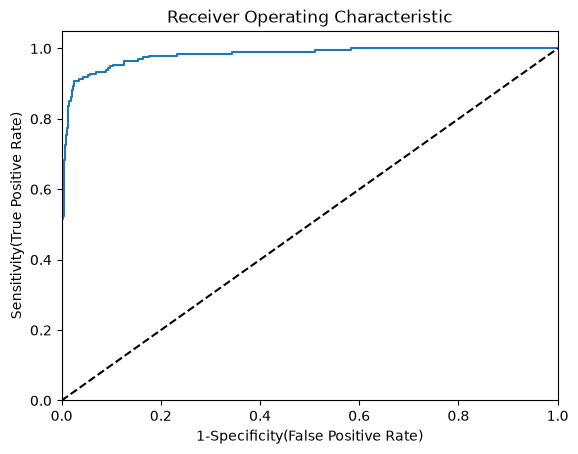

In [30]:
plt.plot(fpr, tpr, label="%s ROC (area = %.2f)" % (algo["label"], algo["auc"]))
plt.plot([0, 1], [0, 1], "k--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("1-Specificity(False Positive Rate)")
plt.ylabel("Sensitivity(True Positive Rate)")
plt.title("Receiver Operating Characteristic")
plt.show()